1. Importing Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model selection
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Machine learning model
from xgboost import XGBClassifier, plot_importance

# Display all columns
pd.set_option("display.max_columns", 120)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

2. Mounting Google Drive

In [2]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/GCI2026_FinalAssignment/Final Assignment"

/content/drive/MyDrive/GCI2026_FinalAssignment/Final Assignment


3. Load the two source table

In [4]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI2026_FinalAssignment/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCI2026_FinalAssignment/Final Assignment/telecom/Record.csv


In [5]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [6]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


4. EDA

In [7]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


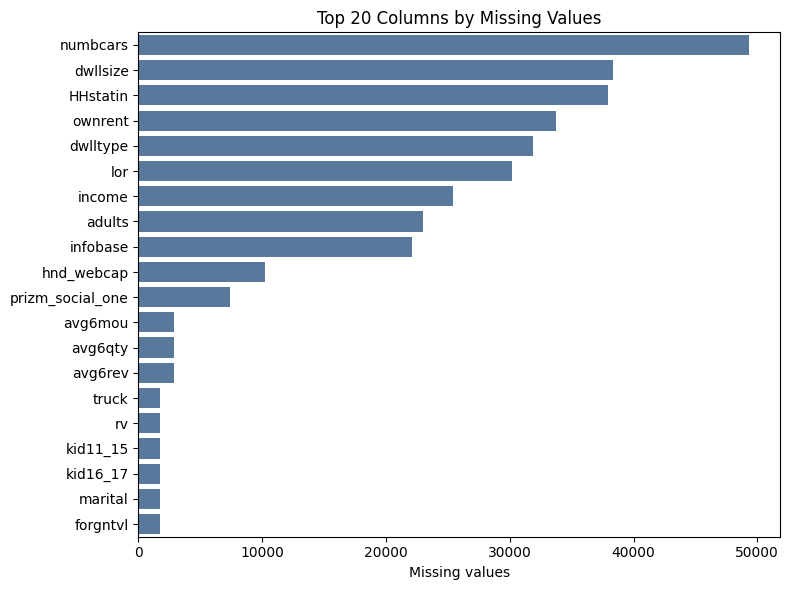

In [8]:
missing_counts = df.isna().sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_counts.values, y=missing_counts.index, color='#4C78A8')
plt.title('Top 20 Columns by Missing Values')
plt.xlabel('Missing values')
plt.ylabel('')
plt.tight_layout()
plt.show()

churn
0    50438
1    49562
Name: count, dtype: int64
Churn rate: 49.56%


/tmp/ipykernel_1958/3386964234.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Stayed (0)', 'Churned (1)'], y=churn_counts.values, palette=['#59A14F', '#E15759'])


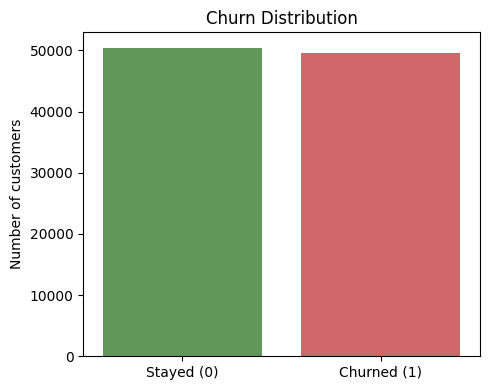

In [9]:
churn_counts = df['churn'].value_counts().sort_index()
churn_rate = df['churn'].mean()

print(churn_counts)
print(f'Churn rate: {churn_rate:.2%}')

plt.figure(figsize=(5, 4))
sns.barplot(x=['Stayed (0)', 'Churned (1)'], y=churn_counts.values, palette=['#59A14F', '#E15759'])
plt.title('Churn Distribution')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

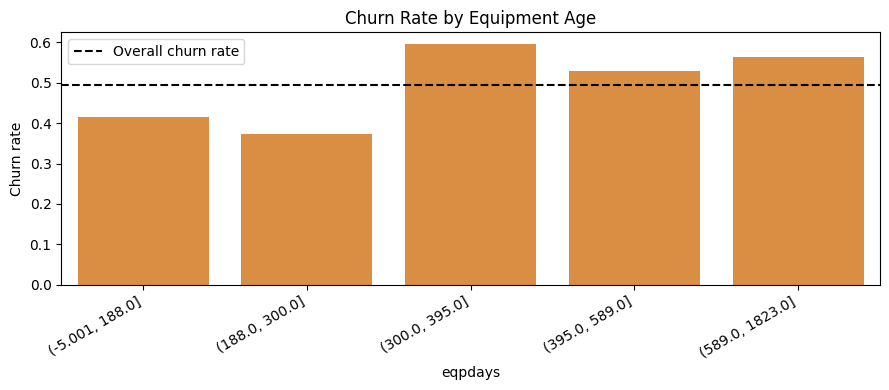

,bucket,count,mean
0,"(-5.001, 188.0]",20006,0.415325
1,"(188.0, 300.0]",20082,0.373817
2,"(300.0, 395.0]",20078,0.595278
3,"(395.0, 589.0]",19868,0.530401
4,"(589.0, 1823.0]",19965,0.563787


In [10]:
def plot_churn_by_bucket(data, feature, bins=5, title=None):
    temp = data[[feature, 'churn']].dropna().copy()
    temp['bucket'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
    summary = temp.groupby('bucket', observed=True)['churn'].agg(['count', 'mean']).reset_index()
    summary['bucket'] = summary['bucket'].astype(str)

    plt.figure(figsize=(9, 4))
    sns.barplot(data=summary, x='bucket', y='mean', color='#F28E2B')
    plt.axhline(data['churn'].mean(), color='black', linestyle='--', label='Overall churn rate')
    plt.title(title or f'Churn Rate by {feature} Bucket')
    plt.xlabel(feature)
    plt.ylabel('Churn rate')
    plt.xticks(rotation=30, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return summary

eqp_summary = plot_churn_by_bucket(df, 'eqpdays', title='Churn Rate by Equipment Age')
eqp_summary

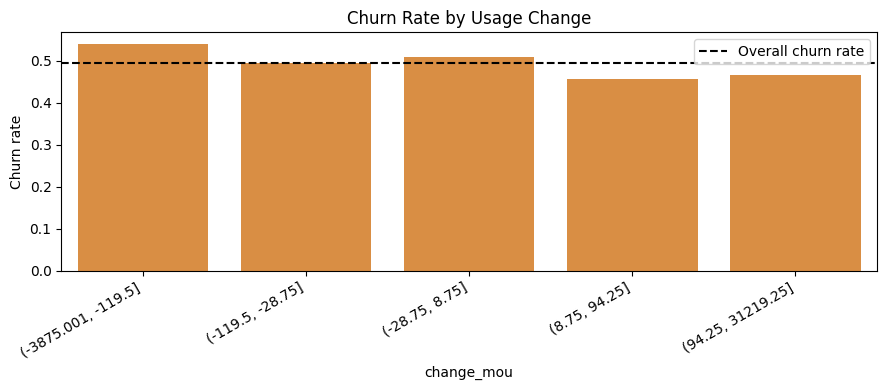

,bucket,count,mean
0,"(-3875.001, -119.5]",19850,0.540353
1,"(-119.5, -28.75]",19838,0.494153
2,"(-28.75, 8.75]",19821,0.508854
3,"(8.75, 94.25]",19808,0.456129
4,"(94.25, 31219.25]",19792,0.466552


In [11]:
usage_change_summary = plot_churn_by_bucket(df, 'change_mou', title='Churn Rate by Usage Change')
usage_change_summary

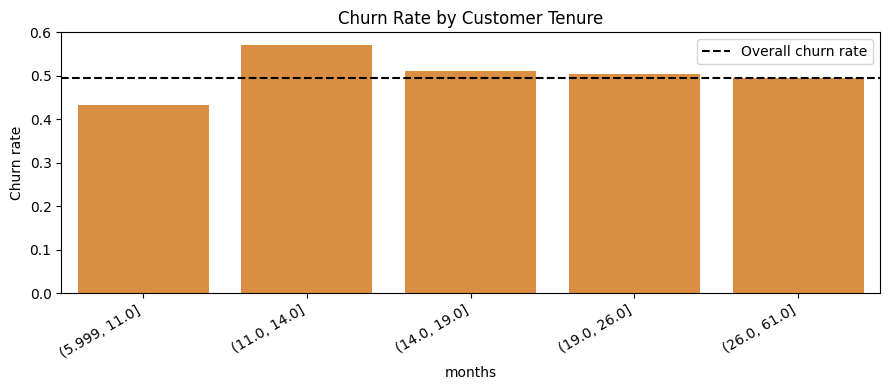

,bucket,count,mean
0,"(5.999, 11.0]",26410,0.433321
1,"(11.0, 14.0]",16236,0.571508
2,"(14.0, 19.0]",17855,0.510221
3,"(19.0, 26.0]",19810,0.503433
4,"(26.0, 61.0]",19689,0.495505


In [12]:
tenure_summary = plot_churn_by_bucket(df, 'months', title='Churn Rate by Customer Tenure')
tenure_summary

# 5. Preprocessing and Model
This notebook uses Logistic Regression because it is interpretable and returns churn probabilities. Those probabilities can be used to rank customers for retention targeting.

In [13]:
target = 'churn'
drop_cols = ['churn', 'Customer_ID']

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target].astype(int)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 77
Categorical features: 21


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=100))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

model = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print('Model: Logistic Regression classifier')
print(f'ROC-AUC: {auc:.4f}')
print(f'Accuracy: {acc:.4f}')
print()
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Model: Logistic Regression classifier
ROC-AUC: 0.6307
Accuracy: 0.5958

Confusion matrix:
[[5865 4223]
 [3862 6050]]

              precision    recall  f1-score   support

           0       0.60      0.58      0.59     10088
           1       0.59      0.61      0.60      9912

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000



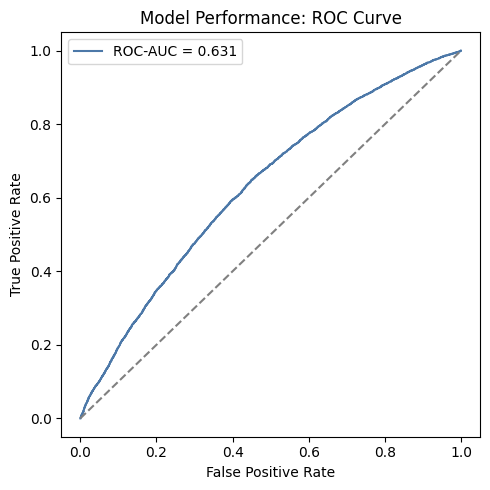

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}', color='#4C78A8')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Performance: ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Model Insights
This section identifies which variables the model uses most strongly. Interpret coefficients carefully: they show association, not guaranteed causation.

In [17]:
feature_names = []
feature_names.extend(numeric_features)

onehot = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names.extend(onehot.get_feature_names_out(categorical_features))

coefs = clf.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'absolute_coefficient': np.abs(coefs)
}).sort_values('absolute_coefficient', ascending=False)

coef_df.head(20)

,feature,coefficient,absolute_coefficient
99,crclscod_JF,0.608428,0.608428
174,ethnic_C,-0.603908,0.603908
24,ccrndmou_Mean,-0.596010,0.596010
93,crclscod_E4,-0.534299,0.534299
25,cc_mou_Mean,0.488290,0.488290
54,adjrev,-0.449628,0.449628
81,crclscod_A2,0.436396,0.436396
53,totrev,0.364013,0.364013
1,mou_Mean,-0.360867,0.360867
183,ethnic_O,0.352194,0.352194


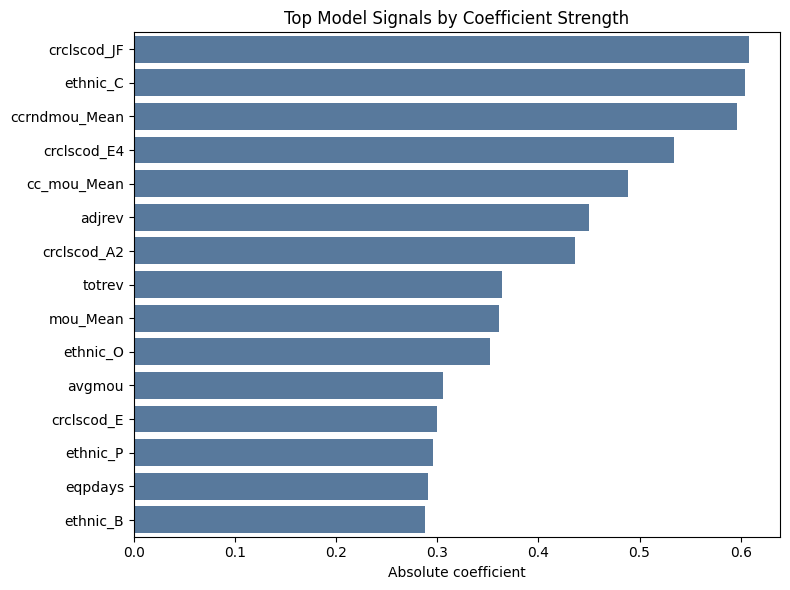

In [18]:
top_coef = coef_df.head(15).copy()

plt.figure(figsize=(8, 6))
sns.barplot(data=top_coef, x='absolute_coefficient', y='feature', color='#4C78A8')
plt.title('Top Model Signals by Coefficient Strength')
plt.xlabel('Absolute coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 7. From Model to Business Proposal
The model should support a recommendation: target the highest-risk customers rather than running a broad retention campaign.

In [19]:
scored = X_test.copy()
scored['actual_churn'] = y_test.values
scored['predicted_churn_probability'] = y_proba
scored['rev_Mean'] = df.loc[X_test.index, 'rev_Mean'].values
scored['annualized_revenue'] = scored['rev_Mean'] * 12

baseline_churn = y_test.mean()
top10 = scored.nlargest(int(len(scored) * 0.10), 'predicted_churn_probability')
top20 = scored.nlargest(int(len(scored) * 0.20), 'predicted_churn_probability')

print(f'Baseline churn rate in test set: {baseline_churn:.2%}')
print(f'Top 10% predicted-risk churn rate: {top10.actual_churn.mean():.2%}')
print(f'Top 20% predicted-risk churn rate: {top20.actual_churn.mean():.2%}')
print(f'Top 20% captures {top20.actual_churn.sum() / y_test.sum():.2%} of all churners in the test set')

Baseline churn rate in test set: 49.56%
Top 10% predicted-risk churn rate: 65.80%
Top 20% predicted-risk churn rate: 64.48%
Top 20% captures 26.02% of all churners in the test set


/tmp/ipykernel_1958/2296087112.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lift_df, x='Group', y='Churn rate', palette=['#BAB0AC', '#F28E2B', '#E15759'])


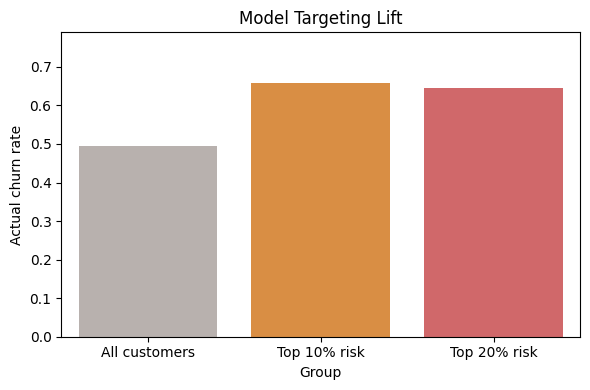

In [20]:
lift_df = pd.DataFrame({
    'Group': ['All customers', 'Top 10% risk', 'Top 20% risk'],
    'Churn rate': [baseline_churn, top10.actual_churn.mean(), top20.actual_churn.mean()]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=lift_df, x='Group', y='Churn rate', palette=['#BAB0AC', '#F28E2B', '#E15759'])
plt.title('Model Targeting Lift')
plt.ylabel('Actual churn rate')
plt.ylim(0, max(lift_df['Churn rate']) * 1.2)
plt.tight_layout()
plt.show()

In [21]:
# Business impact assumptions: change these if you find better cited assumptions.
contact_cost_per_customer = 10
retention_success_rate = 0.15

targeted_customers = len(top20)
actual_churners_targeted = top20['actual_churn'].sum()
retained_revenue = top20.loc[top20['actual_churn'] == 1, 'annualized_revenue'].sum() * retention_success_rate
campaign_cost = targeted_customers * contact_cost_per_customer
net_impact_test = retained_revenue - campaign_cost
net_impact_full_base = net_impact_test * (len(df) / len(y_test))

print(f'Targeted customers in test sample: {targeted_customers:,}')
print(f'Actual churners in targeted group: {actual_churners_targeted:,}')
print(f'Estimated retained annual revenue: {retained_revenue:,.2f}')
print(f'Estimated campaign cost: {campaign_cost:,.2f}')
print(f'Estimated net impact in test sample: {net_impact_test:,.2f}')
print(f'Scaled estimated net impact across full base: {net_impact_full_base:,.2f}')

Targeted customers in test sample: 4,000
Actual churners in targeted group: 2,579
Estimated retained annual revenue: 279,693.44
Estimated campaign cost: 40,000.00
Estimated net impact in test sample: 239,693.44
Scaled estimated net impact across full base: 1,198,467.21
